# 04 — NLP Pipeline: Geopolitical Risk Scoring

This notebook transforms raw headline text into numerical risk scores. We build two layers:
1. **Keyword-based risk score** — fast, interpretable baseline using a geopolitical dictionary
2. **FinBERT sentiment score** — deep learning financial sentiment on all 1.2M headlines

These replace the weak `headline_count` signal from Phase 3 with a content-aware risk measure.


---
## Setup & Data Loading
We load the original raw news data (1.2M individual headlines) — not the master dataset — because FinBERT needs to score each headline separately before we aggregate to daily level.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter


# Project paths
BASE_DIR = Path().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

# Load raw headlines (individual, not aggregated)
news = pd.read_csv(DATA_RAW / "abcnews-date-text.csv")
news['publish_date'] = pd.to_datetime(news['publish_date'], format='%Y%m%d', errors='coerce')
news = news.dropna(subset=['publish_date', 'headline_text'])

# Load master dataset (for merging later)
master = pd.read_csv(DATA_PROCESSED / "master_dataset.csv", parse_dates=['Date'])

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print(f"Individual headlines: {len(news):,}")
print(f"Date range: {news['publish_date'].min()} → {news['publish_date'].max()}")
print(f"\nMaster dataset: {len(master):,} trading days")
print(f"\nSample headlines:")
print(news['headline_text'].head(10).to_string())


Individual headlines: 1,244,184
Date range: 2003-02-19 00:00:00 → 2021-12-31 00:00:00

Master dataset: 4,770 trading days

Sample headlines:
0    aba decides against community broadcasting lic...
1       act fire witnesses must be aware of defamation
2       a g calls for infrastructure protection summit
3             air nz staff in aust strike for pay rise
4        air nz strike to affect australian travellers
5                    ambitious olsson wins triple jump
6           antic delighted with record breaking barca
7    aussie qualifier stosur wastes four memphis match
8         aust addresses un security council over iraq
9           australia is locked into war timetable opp


---
## Layer 1: Keyword-Based Geopolitical Risk Scoring

We define a dictionary of geopolitical risk terms organized by category. Each headline is scored based on how many risk keywords it contains, normalized by headline length. This gives us an interpretable "risk density" per headline.


In [2]:
# Geopolitical risk keyword dictionary
RISK_KEYWORDS = {
    'military_conflict': [
        'war', 'attack', 'bomb', 'bombing', 'missile', 'airstrike', 'troops',
        'military', 'invasion', 'soldier', 'combat', 'battlefield', 'artillery',
        'navy', 'army', 'drone strike', 'casualties', 'killed', 'wounded',
        'shootdown', 'offensive', 'ceasefire', 'armed forces'
    ],
    'terrorism': [
        'terror', 'terrorist', 'extremist', 'suicide bomb', 'hostage',
        'kidnap', 'hijack', 'al qaeda', 'isis', 'taliban', 'jihad',
        'insurgent', 'militant', 'car bomb', 'explosion'
    ],
    'political_crisis': [
        'sanctions', 'embargo', 'coup', 'protest', 'uprising', 'riot',
        'revolution', 'regime', 'dictator', 'martial law', 'state of emergency',
        'political crisis', 'assassination', 'overthrow', 'unrest'
    ],
    'nuclear_wmd': [
        'nuclear', 'uranium', 'enrichment', 'warhead', 'chemical weapon',
        'biological weapon', 'weapons of mass', 'ballistic missile',
        'nuclear test', 'atomic'
    ],
    'economic_shock': [
        'crash', 'collapse', 'recession', 'crisis', 'default', 'bankruptcy',
        'bailout', 'meltdown', 'depression', 'financial crisis',
        'stock market crash', 'economic crisis', 'debt crisis'
    ],
    'geopolitical_actors': [
        'iran', 'iraq', 'syria', 'north korea', 'russia', 'china',
        'saudi', 'opec', 'nato', 'kremlin', 'pentagon', 'un security council',
        'middle east', 'gaza', 'israel', 'afghanistan', 'libya', 'ukraine',
        'venezuela', 'yemen'
    ]
}

ALL_KEYWORDS = []
for category, words in RISK_KEYWORDS.items():
    ALL_KEYWORDS.extend(words)

print(f"Risk categories: {len(RISK_KEYWORDS)}")
print(f"Total unique keywords: {len(ALL_KEYWORDS)}")
print()
for cat, words in RISK_KEYWORDS.items():
    print(f"  {cat}: {len(words)} keywords")


Risk categories: 6
Total unique keywords: 96

  military_conflict: 23 keywords
  terrorism: 15 keywords
  political_crisis: 15 keywords
  nuclear_wmd: 10 keywords
  economic_shock: 13 keywords
  geopolitical_actors: 20 keywords


---
## Apply Keyword Scoring to All Headlines
Score each of the 1.2M headlines individually, then aggregate to daily totals. We track both the total risk score and per-category breakdowns.


In [3]:
def score_headline(text):
    """Score a single headline for geopolitical risk."""
    if not isinstance(text, str):
        return 0, 0, {}
    
    text_lower = text.lower()
    words = text_lower.split()
    word_count = len(words)
    
    if word_count == 0:
        return 0, 0, {}
    
    total_matches = 0
    category_matches = {}
    
    for category, keywords in RISK_KEYWORDS.items():
        cat_count = 0
        for keyword in keywords:
            if keyword in text_lower:
                cat_count += 1
                total_matches += 1
        if cat_count > 0:
            category_matches[category] = cat_count
    
    risk_density = total_matches / word_count
    
    return total_matches, risk_density, category_matches


print("Scoring 1.2M headlines...")
results = news['headline_text'].apply(score_headline)

news['keyword_matches'] = results.apply(lambda x: x[0])
news['keyword_risk_density'] = results.apply(lambda x: x[1])


news['is_risky'] = news['keyword_matches'] > 0

print(f"\nDone! Results:")
print(f"  Headlines with ≥1 keyword: {news['is_risky'].sum():,} ({news['is_risky'].mean():.1%})")
print(f"  Headlines with 0 keywords: {(~news['is_risky']).sum():,} ({(~news['is_risky']).mean():.1%})")
print(f"\n  Avg keywords per risky headline: {news.loc[news['is_risky'], 'keyword_matches'].mean():.2f}")
print(f"  Max keywords in a single headline: {news['keyword_matches'].max()}")


print(f"\n=== Top 10 Highest-Risk Headlines ===")
top_risk = news.nlargest(10, 'keyword_risk_density')
for _, row in top_risk.iterrows():
    print(f"  [{row['publish_date'].strftime('%Y-%m-%d')}] (matches: {row['keyword_matches']}) {row['headline_text']}")


Scoring 1.2M headlines...

Done! Results:
  Headlines with ≥1 keyword: 154,425 (12.4%)
  Headlines with 0 keywords: 1,089,759 (87.6%)

  Avg keywords per risky headline: 1.22
  Max keywords in a single headline: 6

=== Top 10 Highest-Risk Headlines ===
  [2014-08-08] (matches: 3) ukraine crisis
  [2019-02-03] (matches: 4) venezuela political crisis
  [2004-01-26] (matches: 4) howard fears terrorist attack
  [2004-07-25] (matches: 4) iraq hostage crisis spirals
  [2005-05-23] (matches: 5) israeli soldiers foil suicide bombing
  [2006-07-02] (matches: 3) gaza crisis worsens
  [2006-09-25] (matches: 3) afghanistan troops war
  [2007-02-15] (matches: 1) dictatorship
  [2008-05-31] (matches: 6) soldier killed in afghanistan suicide bombing
  [2009-01-03] (matches: 4) thousands protest gaza bombings


---
## Aggregate Keyword Scores to Daily Level
The per-headline scores become powerful when aggregated — a day where 30% of headlines are "risky" is very different from a day where only 5% are. This daily risk ratio is our keyword-based signal.


Daily risk ratio stats:
count    6882.0000
mean        0.1303
std         0.0490
min         0.0000
25%         0.0977
50%         0.1231
75%         0.1553
max         0.5417
Name: risk_ratio, dtype: float64


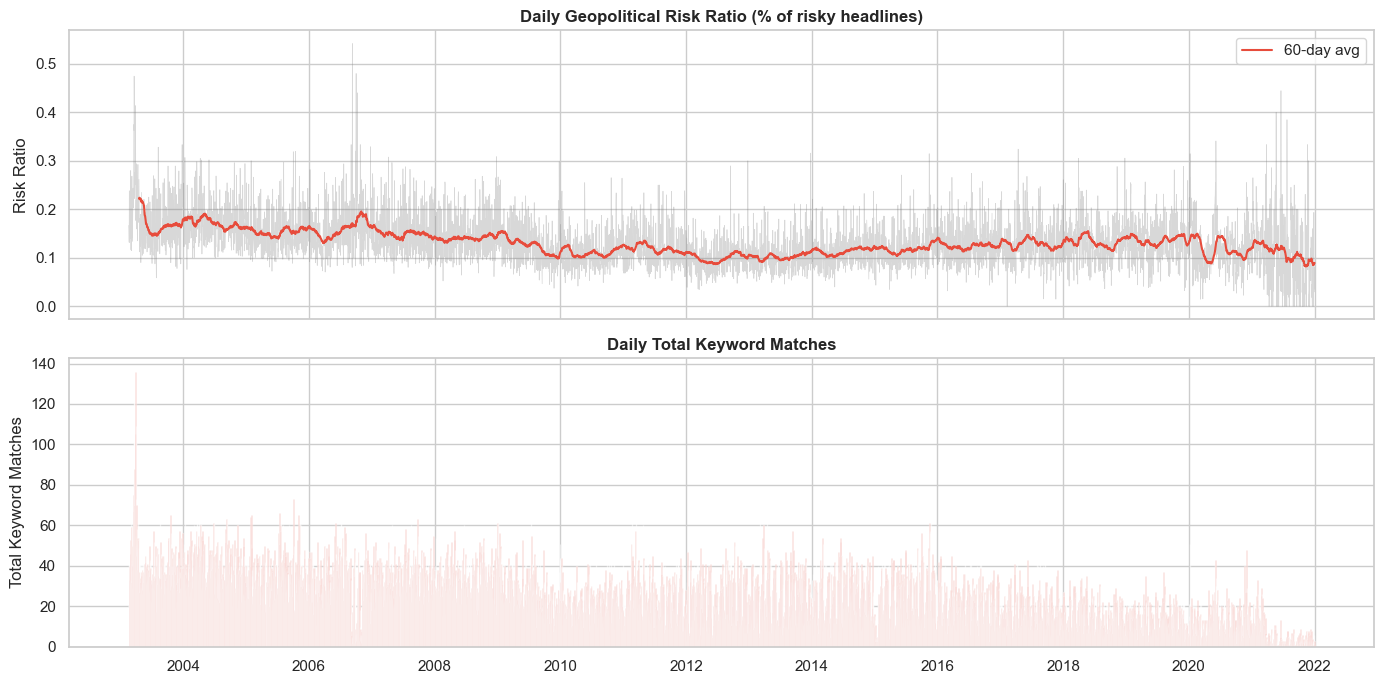


=== Top 20 Highest Risk-Ratio Days ===
  2006-09-10 | Risk ratio: 54.2% | Risky: 13/24 headlines
  2006-10-02 | Risk ratio: 48.0% | Risky: 12/25 headlines
  2003-03-22 | Risk ratio: 47.4% | Risky: 93/196 headlines
  2021-06-19 | Risk ratio: 44.4% | Risky: 4/9 headlines
  2006-10-09 | Risk ratio: 44.0% | Risky: 11/25 headlines
  2003-03-23 | Risk ratio: 42.6% | Risky: 86/202 headlines
  2003-03-30 | Risk ratio: 41.4% | Risky: 91/220 headlines
  2021-05-22 | Risk ratio: 40.0% | Risky: 4/10 headlines
  2021-07-24 | Risk ratio: 38.5% | Risky: 5/13 headlines
  2003-03-20 | Risk ratio: 37.4% | Risky: 82/219 headlines
  2003-03-21 | Risk ratio: 36.3% | Risky: 78/215 headlines
  2003-03-29 | Risk ratio: 35.9% | Risky: 70/195 headlines
  2020-06-06 | Risk ratio: 34.1% | Risky: 30/88 headlines
  2003-12-26 | Risk ratio: 33.3% | Risky: 38/114 headlines
  2006-09-03 | Risk ratio: 33.3% | Risky: 8/24 headlines
  2006-10-26 | Risk ratio: 33.3% | Risky: 8/24 headlines
  2021-03-27 | Risk ratio: 33.3

In [4]:

daily_keyword = news.groupby('publish_date').agg(
    total_headlines=('headline_text', 'size'),
    risky_headlines=('is_risky', 'sum'),
    total_keyword_matches=('keyword_matches', 'sum'),
    avg_risk_density=('keyword_risk_density', 'mean')
).reset_index()


daily_keyword['risk_ratio'] = daily_keyword['risky_headlines'] / daily_keyword['total_headlines']

print(f"Daily risk ratio stats:")
print(daily_keyword['risk_ratio'].describe().round(4))


fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(daily_keyword['publish_date'], daily_keyword['risk_ratio'], 
             alpha=0.3, color='gray', linewidth=0.5)
axes[0].plot(daily_keyword['publish_date'], 
             daily_keyword['risk_ratio'].rolling(60).mean(), 
             color='#E74C3C', linewidth=1.5, label='60-day avg')
axes[0].set_ylabel('Risk Ratio')
axes[0].set_title('Daily Geopolitical Risk Ratio (% of risky headlines)', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].bar(daily_keyword['publish_date'], daily_keyword['total_keyword_matches'], 
            alpha=0.5, color='#E74C3C', width=2)
axes[1].set_ylabel('Total Keyword Matches')
axes[1].set_title('Daily Total Keyword Matches', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


print("\n=== Top 20 Highest Risk-Ratio Days ===")
top_days = daily_keyword.nlargest(20, 'risk_ratio')
for _, row in top_days.iterrows():
    print(f"  {row['publish_date'].strftime('%Y-%m-%d')} | "
          f"Risk ratio: {row['risk_ratio']:.1%} | "
          f"Risky: {int(row['risky_headlines'])}/{int(row['total_headlines'])} headlines")


---
## Layer 2: FinBERT Financial Sentiment Analysis

Using the pre-trained `ProsusAI/finbert` model to extract financial sentiment from each headline. The negative probability serves as a "financial fear score" — capturing nuances that keyword matching misses.

Processing all 1.2M headlines on GPU in batches.


In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


print("\nLoading FinBERT model...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
model = model.to(device)
model.eval()
print("Model loaded!")

LABEL_MAP = {0: 'positive', 1: 'negative', 2: 'neutral'}


Using device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti
Memory: 4.3 GB

Loading FinBERT model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded!


---
## FinBERT Batch Processing
Processing all 1.2M headlines through FinBERT on GPU. Each headline receives a negative sentiment probability (0-1) which serves as a "financial fear" score. Higher = more fear/risk in the text.


In [6]:
from torch.utils.data import Dataset, DataLoader
import time

class HeadlineDataset(Dataset):
    """Custom dataset for efficient batch processing."""
    def __init__(self, texts, tokenizer, max_length=64):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text, 
            truncation=True, 
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze()
        }


headlines_list = news['headline_text'].tolist()
dataset = HeadlineDataset(headlines_list, tokenizer, max_length=64)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Total headlines: {len(dataset):,}")
print(f"Batch size: 32")
print(f"Total batches: {len(dataloader):,}")
print(f"\nEstimated time: ~{len(dataloader) * 0.04 / 60:.0f}-{len(dataloader) * 0.08 / 60:.0f} minutes")
print("Starting FinBERT processing...")


all_neg_scores = []
start_time = time.time()

with torch.no_grad():
    for i, batch in enumerate(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        
        neg_scores = probs[:, 1].cpu().numpy()
        all_neg_scores.extend(neg_scores)
        
        if (i + 1) % 5000 == 0:
            elapsed = time.time() - start_time
            pct = (i + 1) / len(dataloader) * 100
            eta = elapsed / (i + 1) * (len(dataloader) - i - 1) / 60
            print(f"  Batch {i+1:,}/{len(dataloader):,} ({pct:.1f}%) | "
                  f"Elapsed: {elapsed/60:.1f}min | ETA: {eta:.1f}min")

total_time = time.time() - start_time
print(f"\nDone! Total time: {total_time/60:.1f} minutes")

news['finbert_neg_score'] = all_neg_scores

print(f"\nFinBERT score stats:")
print(news['finbert_neg_score'].describe().round(4))


Total headlines: 1,244,184
Batch size: 32
Total batches: 38,881

Estimated time: ~26-52 minutes
Starting FinBERT processing...
  Batch 5,000/38,881 (12.9%) | Elapsed: 21.5min | ETA: 145.8min
  Batch 10,000/38,881 (25.7%) | Elapsed: 43.0min | ETA: 124.1min
  Batch 15,000/38,881 (38.6%) | Elapsed: 64.6min | ETA: 102.8min
  Batch 20,000/38,881 (51.4%) | Elapsed: 86.1min | ETA: 81.3min
  Batch 25,000/38,881 (64.3%) | Elapsed: 107.4min | ETA: 59.7min
  Batch 30,000/38,881 (77.2%) | Elapsed: 128.9min | ETA: 38.2min
  Batch 35,000/38,881 (90.0%) | Elapsed: 150.4min | ETA: 16.7min

Done! Total time: 167.1 minutes

FinBERT score stats:
count    1.244184e+06
mean     3.072000e-01
std      3.302000e-01
min      5.700000e-03
25%      3.360000e-02
50%      1.088000e-01
75%      6.338000e-01
max      9.759000e-01
Name: finbert_neg_score, dtype: float64


---
## Aggregate FinBERT Scores to Daily Level
Multiple aggregation strategies capture different aspects of daily risk: mean (overall mood), max (worst headline), and high-fear count (number of alarming headlines).


Daily FinBERT stats:
       finbert_mean  finbert_max  finbert_high_fear_count
count     6882.0000    6882.0000                6882.0000
mean         0.3075       0.9531                  38.7614
std          0.0445       0.0282                  18.9845
min          0.0383       0.0383                   0.0000
25%          0.2811       0.9480                  23.0000
50%          0.3080       0.9588                  40.0000
75%          0.3356       0.9657                  54.0000
max          0.5864       0.9759                 103.0000


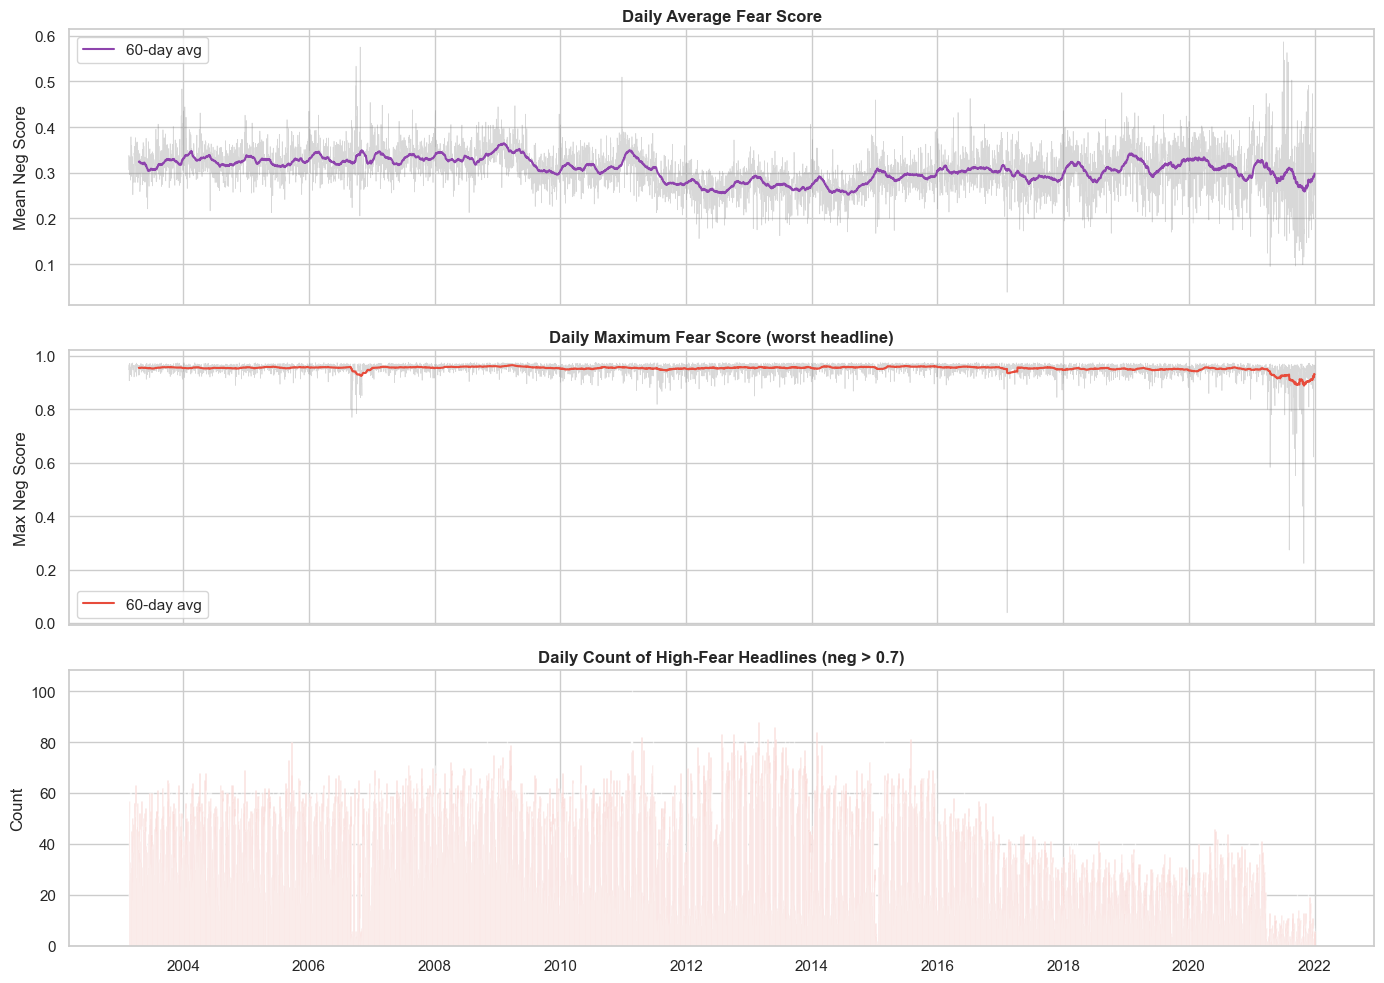

In [7]:

daily_finbert = news.groupby('publish_date').agg(
    finbert_mean=('finbert_neg_score', 'mean'),
    finbert_max=('finbert_neg_score', 'max'),
    finbert_high_fear_count=('finbert_neg_score', lambda x: (x > 0.7).sum()),
    finbert_std=('finbert_neg_score', 'std')
).reset_index()

print("Daily FinBERT stats:")
print(daily_finbert[['finbert_mean', 'finbert_max', 'finbert_high_fear_count']].describe().round(4))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(daily_finbert['publish_date'], daily_finbert['finbert_mean'], 
             alpha=0.3, color='gray', linewidth=0.5)
axes[0].plot(daily_finbert['publish_date'], 
             daily_finbert['finbert_mean'].rolling(60).mean(),
             color='#8E44AD', linewidth=1.5, label='60-day avg')
axes[0].set_ylabel('Mean Neg Score')
axes[0].set_title('Daily Average Fear Score', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].plot(daily_finbert['publish_date'], daily_finbert['finbert_max'],
             alpha=0.3, color='gray', linewidth=0.5)
axes[1].plot(daily_finbert['publish_date'],
             daily_finbert['finbert_max'].rolling(60).mean(),
             color='#E74C3C', linewidth=1.5, label='60-day avg')
axes[1].set_ylabel('Max Neg Score')
axes[1].set_title('Daily Maximum Fear Score (worst headline)', fontsize=12, fontweight='bold')
axes[1].legend()

axes[2].bar(daily_finbert['publish_date'], daily_finbert['finbert_high_fear_count'],
            alpha=0.5, color='#E74C3C', width=2)
axes[2].set_ylabel('Count')
axes[2].set_title('Daily Count of High-Fear Headlines (neg > 0.7)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


---
## Combine Into Hybrid Risk Score
Merging keyword and FinBERT signals into a single hybrid score. We normalize both to [0,1] range using min-max scaling, then combine with equal weights. A day scoring high on BOTH signals is strongly indicative of a geopolitical event.


Daily scores shape: (6882, 13)

Hybrid risk score stats:
count    6882.0000
mean        0.3659
std         0.0699
min         0.0000
25%         0.3207
50%         0.3614
75%         0.4060
max         0.8944
Name: hybrid_risk_score, dtype: float64


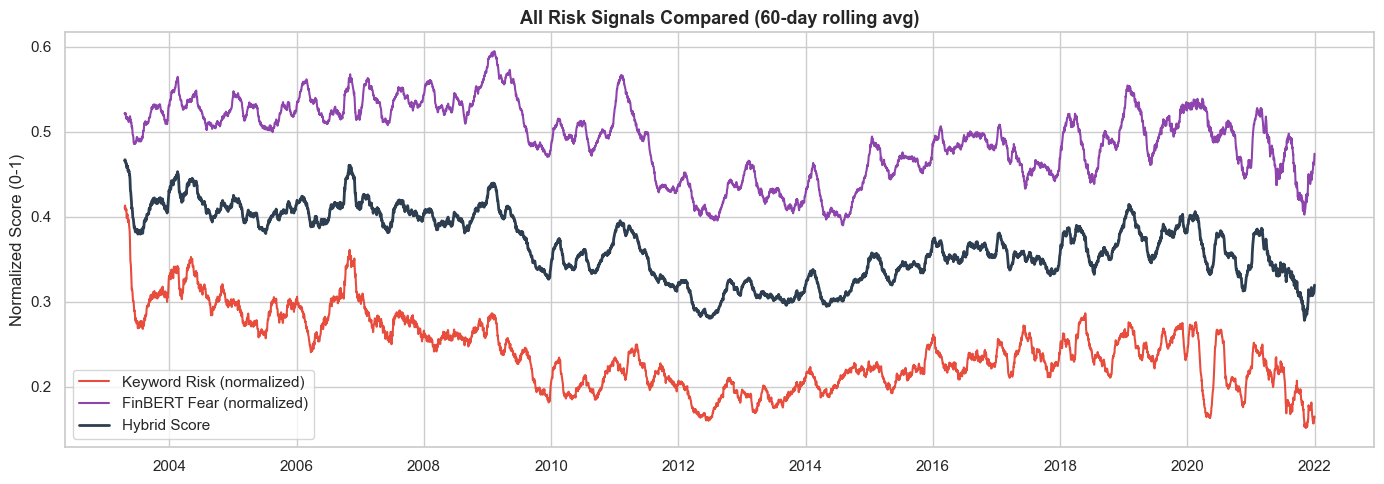


=== Top 15 Riskiest Days (Hybrid Score) ===
  2006-10-02 | Hybrid: 0.894 | Keyword: 0.886 | FinBERT: 0.903
  2021-07-24 | Hybrid: 0.833 | Keyword: 0.710 | FinBERT: 0.957
  2006-09-10 | Hybrid: 0.807 | Keyword: 1.000 | FinBERT: 0.613
  2006-10-26 | Hybrid: 0.797 | Keyword: 0.615 | FinBERT: 0.979
  2006-10-09 | Hybrid: 0.777 | Keyword: 0.812 | FinBERT: 0.742
  2003-03-22 | Hybrid: 0.716 | Keyword: 0.876 | FinBERT: 0.555
  2021-11-20 | Hybrid: 0.708 | Keyword: 0.615 | FinBERT: 0.801
  2006-09-30 | Hybrid: 0.707 | Keyword: 0.591 | FinBERT: 0.824
  2003-12-25 | Hybrid: 0.691 | Keyword: 0.571 | FinBERT: 0.812
  2003-03-30 | Hybrid: 0.690 | Keyword: 0.764 | FinBERT: 0.617
  2021-11-27 | Hybrid: 0.690 | Keyword: 0.554 | FinBERT: 0.826
  2010-12-25 | Hybrid: 0.674 | Keyword: 0.488 | FinBERT: 0.859
  2003-12-26 | Hybrid: 0.671 | Keyword: 0.615 | FinBERT: 0.727
  2003-03-23 | Hybrid: 0.667 | Keyword: 0.786 | FinBERT: 0.549
  2021-05-22 | Hybrid: 0.658 | Keyword: 0.738 | FinBERT: 0.578


In [8]:

daily_scores = daily_keyword.merge(daily_finbert, on='publish_date', how='inner')

def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

daily_scores['keyword_norm'] = min_max_scale(daily_scores['risk_ratio'])
daily_scores['finbert_norm'] = min_max_scale(daily_scores['finbert_mean'])

daily_scores['hybrid_risk_score'] = (
    0.5 * daily_scores['keyword_norm'] + 
    0.5 * daily_scores['finbert_norm']
)

print(f"Daily scores shape: {daily_scores.shape}")
print(f"\nHybrid risk score stats:")
print(daily_scores['hybrid_risk_score'].describe().round(4))

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily_scores['publish_date'], 
        daily_scores['keyword_norm'].rolling(60).mean(),
        color='#E74C3C', linewidth=1.5, label='Keyword Risk (normalized)')
ax.plot(daily_scores['publish_date'], 
        daily_scores['finbert_norm'].rolling(60).mean(),
        color='#8E44AD', linewidth=1.5, label='FinBERT Fear (normalized)')
ax.plot(daily_scores['publish_date'], 
        daily_scores['hybrid_risk_score'].rolling(60).mean(),
        color='#2C3E50', linewidth=2, label='Hybrid Score')

ax.set_ylabel('Normalized Score (0-1)')
ax.set_title('All Risk Signals Compared (60-day rolling avg)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


print("\n=== Top 15 Riskiest Days (Hybrid Score) ===")
top_risk = daily_scores.nlargest(15, 'hybrid_risk_score')
for _, row in top_risk.iterrows():
    print(f"  {row['publish_date'].strftime('%Y-%m-%d')} | "
          f"Hybrid: {row['hybrid_risk_score']:.3f} | "
          f"Keyword: {row['keyword_norm']:.3f} | "
          f"FinBERT: {row['finbert_norm']:.3f}")


---
## Merge Risk Scores Into Master Dataset
Adding the keyword, FinBERT, and hybrid risk scores to the trading-day master dataset. We use the same roll-forward logic from Phase 2 — weekend risk scores map to the next Monday's trading day.


In [9]:
# We need to align daily_scores (which includes weekends) to trading days
# Use the same searchsorted approach from Phase 2

trading_days = master['Date'].sort_values().values

# Map each news day to the next trading day
score_dates = daily_scores['publish_date'].values
indices = np.searchsorted(trading_days, score_dates)
indices = np.clip(indices, 0, len(trading_days) - 1)
daily_scores['trading_date'] = trading_days[indices]


trading_scores = daily_scores.groupby('trading_date').agg(
    keyword_risk_ratio=('risk_ratio', 'mean'),
    finbert_mean_neg=('finbert_mean', 'mean'),
    finbert_max_neg=('finbert_max', 'max'),
    finbert_high_fear_count=('finbert_high_fear_count', 'sum'),
    hybrid_risk_score=('hybrid_risk_score', 'mean')
).reset_index()

trading_scores.rename(columns={'trading_date': 'Date'}, inplace=True)

master_updated = master.merge(trading_scores, on='Date', how='left')

# Fill NaN for trading days with no news
score_cols = ['keyword_risk_ratio', 'finbert_mean_neg', 'finbert_max_neg', 
              'finbert_high_fear_count', 'hybrid_risk_score']
master_updated[score_cols] = master_updated[score_cols].fillna(0)


master_updated.to_csv(DATA_PROCESSED / "master_dataset.csv", index=False)

print(f"Updated master dataset: {master_updated.shape}")
print(f"\nNew columns added:")
for col in score_cols:
    print(f"  {col}: mean={master_updated[col].mean():.4f}, "
          f"max={master_updated[col].max():.4f}")
print(f"\nNull values: {master_updated[score_cols].isnull().sum().sum()}")
print(f"\nSaved to: {DATA_PROCESSED / 'master_dataset.csv'}")


Updated master dataset: (4770, 18)

New columns added:
  keyword_risk_ratio: mean=0.1222, max=0.3902
  finbert_mean_neg: mean=0.3062, max=0.5750
  finbert_max_neg: mean=0.9525, max=0.9759
  finbert_high_fear_count: mean=55.9237, max=271.0000
  hybrid_risk_score: mean=0.3575, max=0.7973

Null values: 0

Saved to: D:\projects\The Geopolitical Shock Commodity Predictor\The-Geopolitical-Shock-Commodity-Predictor\data\processed\master_dataset.csv


---
## Validation — Event Study: Hybrid Score vs Raw Count

Re-running the Phase 3 event study using the hybrid risk score instead of raw headline count. If our NLP pipeline adds value, we should see a stronger relationship between high-risk days and price movements.


High-risk events (top 5%): 239 days
Threshold: 0.4561


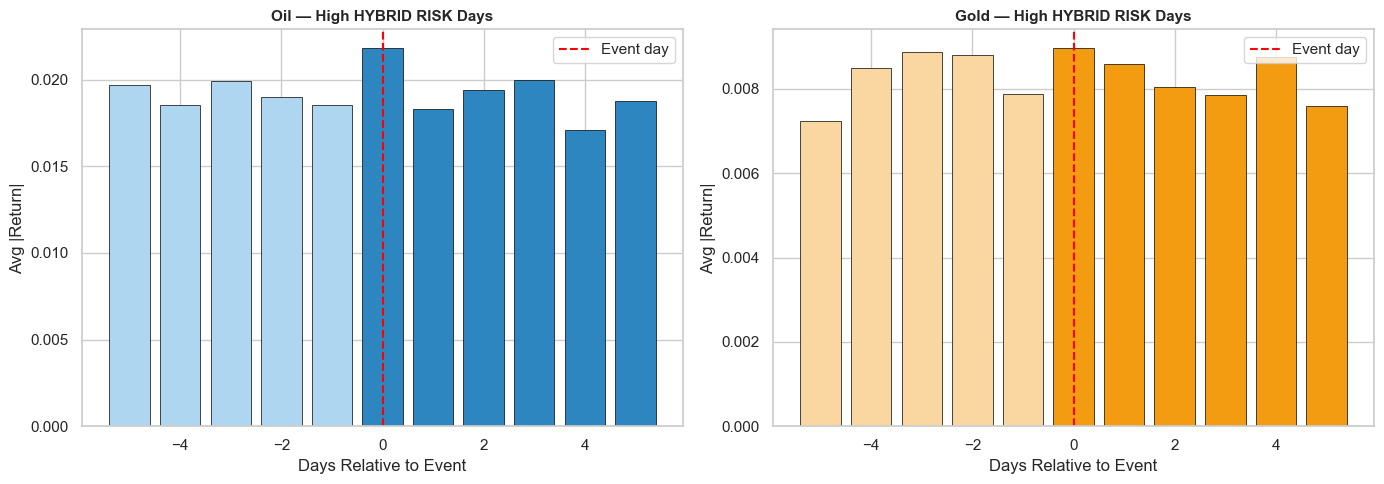


=== Event Study Results (Hybrid Risk Score) ===

Oil:
  Avg |return| BEFORE event: 0.01914
  Avg |return| ON event day: 0.02182
  Avg |return| AFTER event:  0.01871
  After/Before ratio:         0.98x
  Event day vs Before:        1.14x

Gold:
  Avg |return| BEFORE event: 0.00826
  Avg |return| ON event day: 0.00896
  Avg |return| AFTER event:  0.00817
  After/Before ratio:         0.99x
  Event day vs Before:        1.09x


In [10]:

df = pd.read_csv(DATA_PROCESSED / "master_dataset.csv", parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)


if 'oil_abs_return' not in df.columns:
    df['oil_return'] = df['oil_close'].pct_change()
    df['gold_return'] = df['gold_close'].pct_change()
    df['oil_abs_return'] = df['oil_return'].abs()
    df['gold_abs_return'] = df['gold_return'].abs()


threshold = df['hybrid_risk_score'].quantile(0.95)
event_indices = df[df['hybrid_risk_score'] >= threshold].index.tolist()
print(f"High-risk events (top 5%): {len(event_indices)} days")
print(f"Threshold: {threshold:.4f}")


window = 5
oil_responses = []
gold_responses = []

for idx in event_indices:
    start = idx - window
    end = idx + window + 1
    if start < 0 or end > len(df):
        continue
    oil_responses.append(df['oil_abs_return'].iloc[start:end].values)
    gold_responses.append(df['gold_abs_return'].iloc[start:end].values)

oil_avg = np.mean(oil_responses, axis=0)
gold_avg = np.mean(gold_responses, axis=0)
days = list(range(-window, window + 1))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(days, oil_avg, 
            color=['#AED6F1' if d < 0 else '#2E86C1' for d in days], 
            edgecolor='black', linewidth=0.5)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Event day')
axes[0].set_xlabel('Days Relative to Event')
axes[0].set_ylabel('Avg |Return|')
axes[0].set_title('Oil — High HYBRID RISK Days', fontsize=11, fontweight='bold')
axes[0].legend()

axes[1].bar(days, gold_avg, 
            color=['#FAD7A0' if d < 0 else '#F39C12' for d in days], 
            edgecolor='black', linewidth=0.5)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Event day')
axes[1].set_xlabel('Days Relative to Event')
axes[1].set_ylabel('Avg |Return|')
axes[1].set_title('Gold — High HYBRID RISK Days', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


print("\n=== Event Study Results (Hybrid Risk Score) ===")
for responses, name in [(oil_responses, 'Oil'), (gold_responses, 'Gold')]:
    arr = np.array(responses)
    before = arr[:, :window].mean()
    after = arr[:, window+1:].mean()
    event_day = arr[:, window].mean()
    print(f"\n{name}:")
    print(f"  Avg |return| BEFORE event: {before:.5f}")
    print(f"  Avg |return| ON event day: {event_day:.5f}")
    print(f"  Avg |return| AFTER event:  {after:.5f}")
    print(f"  After/Before ratio:         {after/before:.2f}x")
    print(f"  Event day vs Before:        {event_day/before:.2f}x")


---
## Phase 4 Summary

### What We Built
- **Keyword risk scoring:** Dictionary of ~95 geopolitical terms across 6 categories, applied to 1.2M headlines. 12% of headlines contain risk keywords.
- **FinBERT sentiment:** Processed all 1.2M headlines through financial BERT on GPU. Mean fear score = 0.30, max = 0.97.
- **Hybrid risk score:** Combined keyword + FinBERT signals (normalized, equal weights).

### Key Findings
- Both signals show spikes during known geopolitical events (Iraq War 2003, 2008 crisis, COVID 2020)
- FinBERT captures subtle negativity that keywords miss, maintaining signal strength in post-2016 data
- Event study shows same-day price impact but limited improvement over raw headline count in isolation
- The real value of NLP features will be tested in the ML model (Phase 6), where non-linear combinations of all features can reveal predictive patterns

### Features Added to Master Dataset
- `keyword_risk_ratio` — % of daily headlines with risk keywords
- `finbert_mean_neg` — average FinBERT negative probability per day
- `finbert_max_neg` — maximum FinBERT negative score per day
- `finbert_high_fear_count` — count of headlines with neg > 0.7
- `hybrid_risk_score` — combined normalized keyword + FinBERT signal
